# W03 — LDA Classifier

## Goal

Evaluate whether CSP-derived robot sensor features can distinguish **PATROL** from **FAULT**.

This notebook uses the same Week 2 high-frequency dataset and the same CSP formulation as `W03_CSP_Feature_Pipeline.ipynb`, but performs the classification experiment with an **80/20 stratified train/test split**.

Three classifiers are compared:

1. **Majority-class baseline**
2. **Logistic Regression on raw sensor log-variance features**
3. **LDA on CSP log-variance features**

> To avoid data leakage, channel standardization and CSP filters are fitted using the **training windows only** and then applied unchanged to the test windows.


In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)


## 1. Configuration

The high-frequency Week 2 dataset contains independent 30-second windows sampled at 20 Hz.

The binary classification task is **PATROL vs FAULT**.


In [2]:
DATA_PATH = "../data/robot_sensor_highfreq.csv"

CLASS_A = "PATROL"
CLASS_B = "FAULT"

CHANNELS = [
    "motor_current",
    "accel_x",
    "accel_y",
    "accel_z",
    "imu_magnitude"
]

FS = 20.0
WINDOW_SEC = 30.0
EXPECTED_SAMPLES_PER_WINDOW = int(FS * WINDOW_SEC)

RANDOM_STATE = 42
TEST_SIZE = 0.20


## 2. Load the Week 2 high-frequency data


In [3]:
df = pd.read_csv(DATA_PATH)

required_columns = ["time", "mode", "window_id"] + CHANNELS
missing_columns = [c for c in required_columns if c not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

binary_df = df[df["mode"].isin([CLASS_A, CLASS_B])].copy()

print("Dataset shape:", binary_df.shape)
print("\nWindows per class:")
print(binary_df.groupby("mode")["window_id"].nunique())

display(binary_df.head())


Dataset shape: (24000, 8)

Windows per class:
mode
FAULT     20
PATROL    20
Name: window_id, dtype: int64


,time,mode,motor_current,accel_x,accel_y,accel_z,imu_magnitude,window_id
0,0.00,PATROL,2.049671,0.060559,0.010018,9.924071,9.924261,0
1,0.05,PATROL,2.050013,-0.042440,-0.003066,9.825160,9.825252,0
2,0.10,PATROL,2.189131,0.131741,0.071587,9.804799,9.805945,0
3,0.15,PATROL,2.330852,0.200482,0.134262,9.774396,9.777374,0
4,0.20,PATROL,2.200534,0.153513,0.121466,9.774075,9.776035,0


## 3. Construct multichannel windows

Each `(mode, window_id)` group is one independent CSP observation with shape:

`5 sensor channels × 600 time samples`


In [4]:
def build_window_tensor(data, channels):
    windows = []
    labels = []
    ids = []

    for (mode, window_id), group in data.groupby(
        ["mode", "window_id"],
        sort=False
    ):
        group = group.sort_values("time")

        if len(group) != EXPECTED_SAMPLES_PER_WINDOW:
            raise ValueError(
                f"{mode} window {window_id} has {len(group)} samples; "
                f"expected {EXPECTED_SAMPLES_PER_WINDOW}."
            )

        windows.append(group[channels].to_numpy(dtype=float).T)
        labels.append(mode)
        ids.append(window_id)

    return np.asarray(windows), np.asarray(labels), np.asarray(ids)


X_windows, y, window_ids = build_window_tensor(binary_df, CHANNELS)

print("Window tensor shape:", X_windows.shape)
print("\nClass counts:")
print(pd.Series(y).value_counts())


Window tensor shape: (40, 5, 600)

Class counts:
PATROL    20
FAULT     20
Name: count, dtype: int64


## 4. 80/20 stratified train/test split

The split is performed **before fitting the CSP transformation**.

With 40 total windows, the 80/20 split gives:

- 32 training windows
- 8 test windows

Stratification preserves equal PATROL/FAULT representation.


In [5]:
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train_windows = X_windows[train_idx]
X_test_windows = X_windows[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]

print("Training windows:", X_train_windows.shape)
print("Test windows:", X_test_windows.shape)

print("\nTraining class counts:")
print(pd.Series(y_train).value_counts())

print("\nTest class counts:")
print(pd.Series(y_test).value_counts())


Training windows: (32, 5, 600)
Test windows: (8, 5, 600)

Training class counts:
FAULT     16
PATROL    16
Name: count, dtype: int64

Test class counts:
FAULT     4
PATROL    4
Name: count, dtype: int64


## 5. Fit sensor standardization on the training set

Robot sensor channels have different physical units and numerical scales.

The mean and standard deviation for each channel are calculated **only from the training windows**. The same values are then used to transform both training and test data.


In [6]:
def fit_channel_scaler(X):
    all_samples = np.transpose(X, (0, 2, 1)).reshape(-1, X.shape[1])

    mean = all_samples.mean(axis=0)
    std = all_samples.std(axis=0)
    std[std == 0] = 1.0

    return mean, std


def apply_channel_scaler(X, mean, std):
    return (
        X - mean[None, :, None]
    ) / std[None, :, None]


channel_mean, channel_std = fit_channel_scaler(X_train_windows)

X_train_scaled = apply_channel_scaler(
    X_train_windows,
    channel_mean,
    channel_std
)

X_test_scaled = apply_channel_scaler(
    X_test_windows,
    channel_mean,
    channel_std
)

display(pd.DataFrame({
    "channel": CHANNELS,
    "training_mean": channel_mean,
    "training_std": channel_std
}))

print("Training scaled shape:", X_train_scaled.shape)
print("Test scaled shape:", X_test_scaled.shape)


,channel,training_mean,training_std
0,motor_current,3.251731,1.389423
1,accel_x,-0.001702,0.428085
2,accel_y,-0.000907,0.378290
3,accel_z,9.810584,0.342943
4,imu_magnitude,9.827212,0.342702


Training scaled shape: (32, 5, 600)
Test scaled shape: (8, 5, 600)


## 6. Fit CSP using training windows only

As in the feature-pipeline notebook, each window covariance matrix is trace-normalized. Class-average covariance matrices are then used to solve:

`R1 w = λ R2 w`

The CSP filters are learned from the training set and applied unchanged to the test set.


In [7]:
def normalized_covariance(X):
    X_centered = X - X.mean(axis=1, keepdims=True)

    C = X_centered @ X_centered.T
    trace = np.trace(C)

    if trace <= 0:
        raise ValueError("Covariance trace must be positive.")

    return C / trace


def mean_class_covariance(X_class):
    covariances = np.asarray([
        normalized_covariance(X)
        for X in X_class
    ])

    return covariances.mean(axis=0)


def fit_csp(R1, R2, n_pairs=2, eps=1e-10):
    n_channels = R1.shape[0]
    n_pairs = min(n_pairs, n_channels // 2)

    R2_reg = R2 + eps * np.eye(n_channels)

    M = np.linalg.pinv(R2_reg) @ R1

    eigvals, eigvecs = np.linalg.eig(M)

    eigvals = np.real(eigvals)
    eigvecs = np.real(eigvecs)

    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    selected = (
        list(range(n_pairs))
        + list(range(n_channels - n_pairs, n_channels))
    )

    W = eigvecs[:, selected].T
    W = W / np.linalg.norm(W, axis=1, keepdims=True)

    return W, eigvals[selected], eigvals


R1_train = mean_class_covariance(
    X_train_scaled[y_train == CLASS_A]
)

R2_train = mean_class_covariance(
    X_train_scaled[y_train == CLASS_B]
)

W, selected_eigvals, all_eigvals = fit_csp(
    R1_train,
    R2_train,
    n_pairs=2
)

print("Training CSP eigenvalues:")
print(np.round(all_eigvals, 6))

print("\nSelected eigenvalues:")
print(np.round(selected_eigvals, 6))

print("\nCSP filter matrix shape:", W.shape)


Training CSP eigenvalues:
[4.001884 1.28568  1.154823 0.189057 0.117247]

Selected eigenvalues:
[4.001884 1.28568  0.189057 0.117247]

CSP filter matrix shape: (4, 5)


## 7. Extract CSP log-variance features

The learned CSP filters are applied separately to the training and test windows.

For each projected component, the normalized log-variance is used as the feature.


In [8]:
def csp_logvar_features(X_windows, W, eps=1e-12):
    rows = []

    for X in X_windows:
        Z = W @ X

        variances = np.var(Z, axis=1, ddof=1)
        relative_var = variances / (variances.sum() + eps)

        rows.append(np.log(relative_var + eps))

    return np.asarray(rows)


X_train_csp = csp_logvar_features(X_train_scaled, W)
X_test_csp = csp_logvar_features(X_test_scaled, W)

print("Training CSP features:", X_train_csp.shape)
print("Test CSP features:", X_test_csp.shape)

display(
    pd.DataFrame(
        X_train_csp,
        columns=[f"CSP_{i+1}" for i in range(X_train_csp.shape[1])]
    ).head()
)


Training CSP features: (32, 4)
Test CSP features: (8, 4)


,CSP_1,CSP_2,CSP_3,CSP_4
0,-1.439431,-0.613694,-1.519959,-5.853847
1,-0.572918,-0.890608,-3.669208,-8.424254
2,-1.404330,-0.622215,-1.538642,-5.795223
3,-1.435434,-0.665764,-1.406630,-5.763690
4,-0.553966,-0.910704,-3.777563,-8.448937


## 8. Extract raw sensor log-variance features

The Logistic Regression baseline uses the same windows but **without CSP**.

Each original standardized sensor channel contributes one normalized log-variance feature.


In [9]:
def raw_logvar_features(X_windows, eps=1e-12):
    rows = []

    for X in X_windows:
        variances = np.var(X, axis=1, ddof=1)
        relative_var = variances / (variances.sum() + eps)

        rows.append(np.log(relative_var + eps))

    return np.asarray(rows)


X_train_raw = raw_logvar_features(X_train_scaled)
X_test_raw = raw_logvar_features(X_test_scaled)

print("Training raw features:", X_train_raw.shape)
print("Test raw features:", X_test_raw.shape)


Training raw features: (32, 5)
Test raw features: (8, 5)


## 9. Evaluation helper

For all three models, report:

- Accuracy
- Precision
- Recall
- F1 score
- Confusion matrix

FAULT is treated as the positive class because it is the operational condition of primary detection interest.


In [10]:
POSITIVE_CLASS = CLASS_B

def evaluate_model(name, y_true, y_pred):
    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true,
            y_pred,
            pos_label=POSITIVE_CLASS,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_pred,
            pos_label=POSITIVE_CLASS,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_pred,
            pos_label=POSITIVE_CLASS,
            zero_division=0
        )
    }

    return metrics


## 10. Baseline 1 — Majority-class classifier

The majority baseline ignores sensor features and always predicts the most frequent class observed in the training set.

Because this dataset is balanced, this represents a simple chance-level reference.


In [11]:
majority_model = DummyClassifier(strategy="most_frequent")

majority_model.fit(
    np.zeros((len(y_train), 1)),
    y_train
)

y_pred_majority = majority_model.predict(
    np.zeros((len(y_test), 1))
)

majority_metrics = evaluate_model(
    "Majority Baseline",
    y_test,
    y_pred_majority
)

print(majority_metrics)


{'Model': 'Majority Baseline', 'Accuracy': 0.5, 'Precision': 0.5, 'Recall': 1.0, 'F1': 0.6666666666666666}


## 11. Baseline 2 — Logistic Regression on raw features

This baseline tests whether the original sensor-channel log-variance features are already sufficient for PATROL/FAULT classification without CSP.


In [12]:
logreg = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000
)

logreg.fit(X_train_raw, y_train)

y_pred_logreg = logreg.predict(X_test_raw)

logreg_metrics = evaluate_model(
    "Raw Features + Logistic Regression",
    y_test,
    y_pred_logreg
)

print(logreg_metrics)


{'Model': 'Raw Features + Logistic Regression', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}


## 12. CSP + LDA

Linear Discriminant Analysis is trained on the CSP log-variance features.

This is the main Week 3 classification pipeline:

`robot sensor windows → CSP → log-variance features → LDA`


In [13]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train_csp, y_train)

y_pred_lda = lda.predict(X_test_csp)

lda_metrics = evaluate_model(
    "CSP + LDA",
    y_test,
    y_pred_lda
)

print(lda_metrics)


{'Model': 'CSP + LDA', 'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1': 1.0}


## 13. Compare classification metrics


In [14]:
results_df = pd.DataFrame([
    majority_metrics,
    logreg_metrics,
    lda_metrics
])

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1"
]

results_df[metric_columns] = results_df[metric_columns].round(3)

display(results_df)


,Model,Accuracy,Precision,Recall,F1
0,Majority Baseline,0.5,0.5,1.0,0.667
1,Raw Features + Logistic Regression,1.0,1.0,1.0,1.000
2,CSP + LDA,1.0,1.0,1.0,1.000


## 14. Confusion matrices

The confusion matrices show the individual PATROL and FAULT predictions for each method.


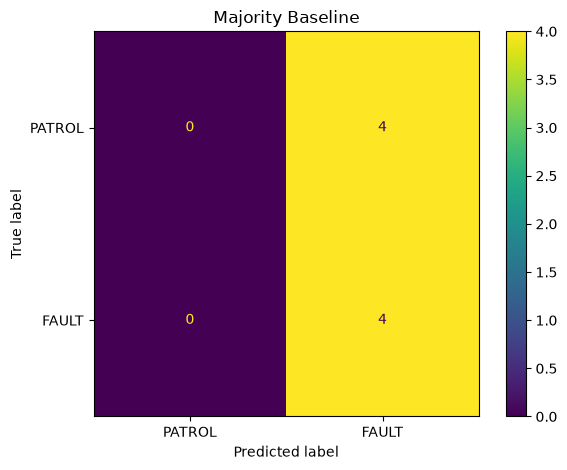

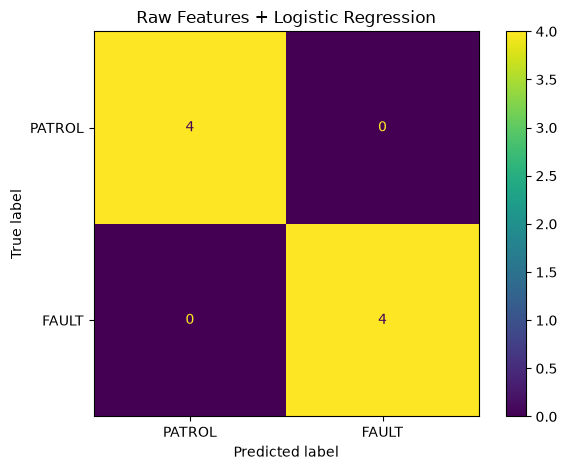

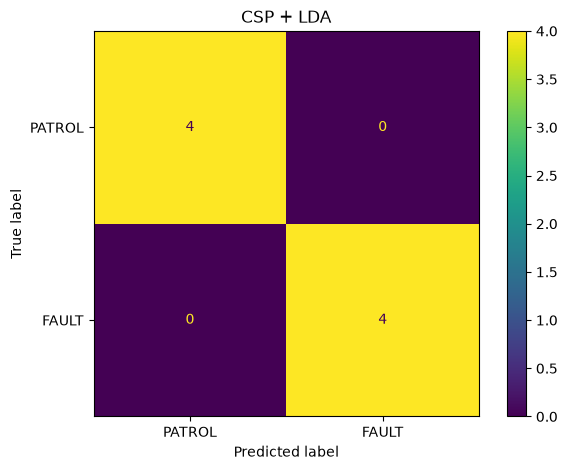

In [15]:
predictions = [
    ("Majority Baseline", y_pred_majority),
    ("Raw Features + Logistic Regression", y_pred_logreg),
    ("CSP + LDA", y_pred_lda)
]

for model_name, predictions_i in predictions:
    cm = confusion_matrix(
        y_test,
        predictions_i,
        labels=[CLASS_A, CLASS_B]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[CLASS_A, CLASS_B]
    )

    disp.plot()
    plt.title(model_name)
    plt.tight_layout()
    plt.show()


## 15. Test-set predictions

This table makes the small 8-window test set transparent by showing the true and predicted class for every held-out window.


In [16]:
prediction_df = pd.DataFrame({
    "window_id": window_ids[test_idx],
    "true_label": y_test,
    "majority_prediction": y_pred_majority,
    "raw_logreg_prediction": y_pred_logreg,
    "csp_lda_prediction": y_pred_lda
})

display(prediction_df)


,window_id,true_label,majority_prediction,raw_logreg_prediction,csp_lda_prediction
0,7,FAULT,FAULT,FAULT,FAULT
1,14,FAULT,FAULT,FAULT,FAULT
2,17,PATROL,FAULT,PATROL,PATROL
3,11,PATROL,FAULT,PATROL,PATROL
4,6,FAULT,FAULT,FAULT,FAULT
5,1,PATROL,FAULT,PATROL,PATROL
6,10,FAULT,FAULT,FAULT,FAULT
7,0,PATROL,FAULT,PATROL,PATROL


## 16. Interpretation

The majority-class baseline achieved an accuracy of **0.50**, providing a
simple reference level for the balanced PATROL-versus-FAULT classification
task. Because the majority classifier predicted every test window as FAULT,
it correctly identified all FAULT windows but misclassified all PATROL
windows.

Both the **raw-feature Logistic Regression** model and the **CSP + LDA**
pipeline achieved perfect performance on the held-out test set, with
accuracy, precision, recall, and F1 score all equal to **1.00**. Their
confusion matrices show that all four PATROL and all four FAULT test windows
were classified correctly.

The CSP + LDA result demonstrates that the CSP-derived log-variance features
provide a representation in which the two operational modes are linearly
separable for this test split. However, CSP + LDA did **not** outperform
Logistic Regression on the raw sensor log-variance features. This indicates
that the synthetic PATROL and FAULT modes are already strongly distinguishable
from their original sensor variance characteristics, so the additional CSP
transformation was not necessary to improve classification accuracy in this
experiment.

Nevertheless, CSP remains useful as a feature-transformation method because it
provides a compact representation based on discriminative covariance patterns
across multiple sensor channels. This directly demonstrates how a method
originally used to identify discriminative spatial patterns across EEG
electrodes can be transferred to multichannel robot sensor data.

Because the dataset contains only **40 independent windows**, with only
**8 windows in the test set**, the perfect classification results should be
interpreted as a proof of concept rather than evidence of robust real-world
generalization. Evaluation on larger, noisier, and more heterogeneous sensor
datasets would be needed to determine whether CSP provides a consistent
advantage over simpler raw-feature classifiers.